# Modules EDA — `g4o_modules` (dashboard MySQL)

Exploratory data analysis on module adoption, pricing config, and company segmentation.

## 1. Setup & Connection

In [2]:
import os
import warnings
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 110})

MYSQL_HOST = os.environ.get("MYSQL_HOST", "127.0.0.1")
MYSQL_PORT = int(os.environ.get("MYSQL_PORT", "3306"))
MYSQL_USER = os.environ.get("MYSQL_USER", "root")
MYSQL_PASSWORD = os.environ.get("MYSQL_PASSWORD", "bansila_root")
MYSQL_DB = os.environ.get("MYSQL_DATABASE", "bansila_analytics")

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}",
    pool_pre_ping=True,
)
conn = engine.connect()
print(f"Connected: {MYSQL_DB} @ {MYSQL_HOST}:{MYSQL_PORT} as {MYSQL_USER}")


Connected: bansila_analytics @ 127.0.0.1:3306 as root


## 2. Data Overview & Temporary Slice

In [2]:
# Drop and recreate temp table for the session
conn.execute(text("DROP TEMPORARY TABLE IF EXISTS tmp_modules"))
conn.commit()

# Exclude test company 97
ddl = text("""
CREATE TEMPORARY TABLE tmp_modules AS
SELECT *
FROM g4o_modules
WHERE company_id IS NOT NULL AND company_id != 97
""")
conn.execute(ddl)
conn.commit()

meta = pd.read_sql(text("""
    SELECT 
        COUNT(*) as n_rows,
        COUNT(DISTINCT company_id) as n_companies,
        MIN(created_at) as min_created,
        MAX(created_at) as max_created
    FROM tmp_modules
"""), conn)
display(meta)

sample_df = pd.read_sql(text("SELECT * FROM tmp_modules LIMIT 5"), conn)
display(sample_df)


,n_rows,n_companies,min_created,max_created
0,48420,6077,2023-02-21 00:22:09,2026-04-17 15:52:22


,id,company_id,key,value,next_billing,data,sequence,created_at,updated_at,deleted_at
0,6,3348,usage_period,1,2024-12-16,"{""min_quantity"":0}",0,2023-02-21 00:22:09,2025-03-17 09:50:37,None
1,7,3348,users,3,2024-12-16,"{""price"":20000,""free_user"":3}",1,2023-02-21 00:22:09,2024-12-16 14:47:27,None
2,8,3348,bookkeeping,1,2024-12-16,"{""price"":80000}",2,2023-02-21 00:22:09,2024-12-16 14:47:27,None
3,9,3348,vat_invoice,0,2024-05-26,"{""price"":960000}",7,2023-02-21 00:22:09,2024-12-16 14:47:27,None
4,11,3356,usage_period,1,2023-03-07,"{""min_quantity"":0}",0,2023-02-21 06:44:52,2025-03-17 09:50:37,None


## 3. Module Type Distribution

,module_type,count
0,usage_period,6077
1,users,6077
2,bookkeeping,6077
3,vat_invoice,6077
4,payroll,6028
5,inventory,6028
6,accounting,6028
7,cash_basis_accounting,6028


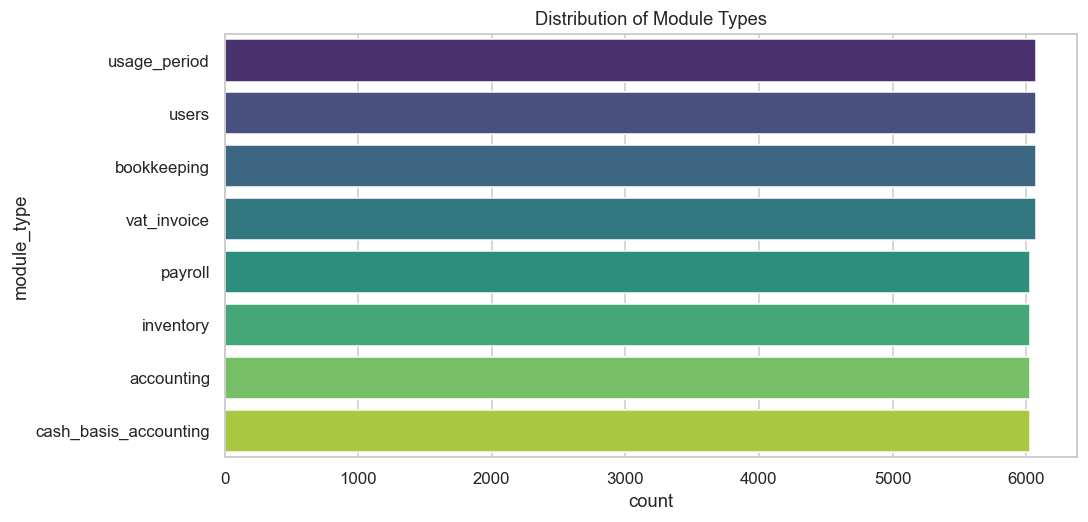

In [3]:
type_df = pd.read_sql(text("""
    SELECT `key` as module_type, COUNT(*) as count
    FROM tmp_modules
    GROUP BY `key`
    ORDER BY count DESC
"""), conn)
display(type_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=type_df, x='count', y='module_type', palette='viridis')
plt.title("Distribution of Module Types")
plt.show()


## 4. Module Pricing Analysis (JSON parsing)

In [4]:
# Fetch raw data to parse JSON in pandas
raw_data_df = pd.read_sql(text("SELECT `key`, data FROM tmp_modules WHERE data IS NOT NULL AND data != ''"), conn)

def extract_price(json_str):
    try:
        data = json.loads(json_str)
        return data.get('price', np.nan)
    except:
        return np.nan

raw_data_df['extracted_price'] = raw_data_df['data'].apply(extract_price)

price_summary = raw_data_df.groupby('key')['extracted_price'].agg(['count', 'mean', 'median', 'min', 'max']).dropna()
display(price_summary.round(2))


,count,mean,median,min,max
key,,,,,
accounting,6028,77648.31,80000.0,0.0,80000.0
bookkeeping,6077,76705.07,80000.0,0.0,114192.0
cash_basis_accounting,6028,49863.14,50000.0,0.0,80000.0
inventory,6028,77942.93,80000.0,0.0,80000.0
payroll,6028,49431.82,50000.0,0.0,80000.0
users,6077,19986.84,20000.0,0.0,20000.0
vat_invoice,6077,943273.33,960000.0,0.0,1920000.0


## 5. Company Module Adoption

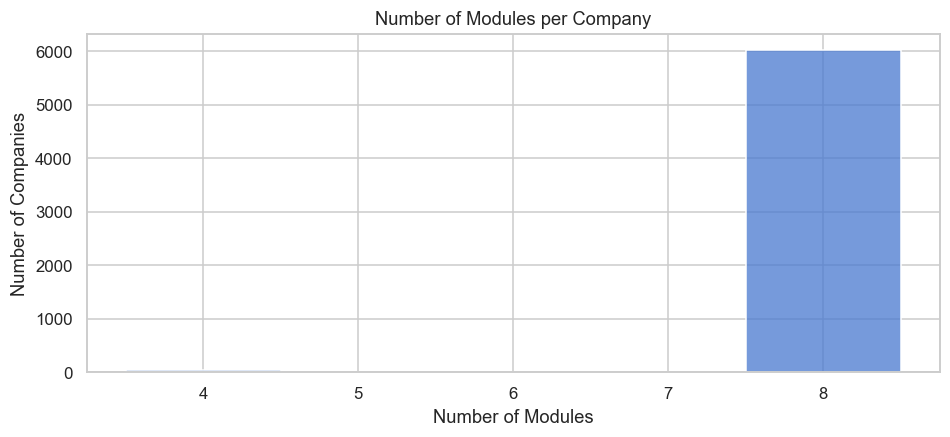

In [5]:
adopt_df = pd.read_sql(text("""
    SELECT company_id, COUNT(*) as num_modules
    FROM tmp_modules
    GROUP BY company_id
"""), conn)

plt.figure(figsize=(10, 4))
sns.histplot(adopt_df['num_modules'], bins=20, discrete=True)
plt.title("Number of Modules per Company")
plt.xlabel("Number of Modules")
plt.ylabel("Number of Companies")
plt.show()


## 6. Module Combinations

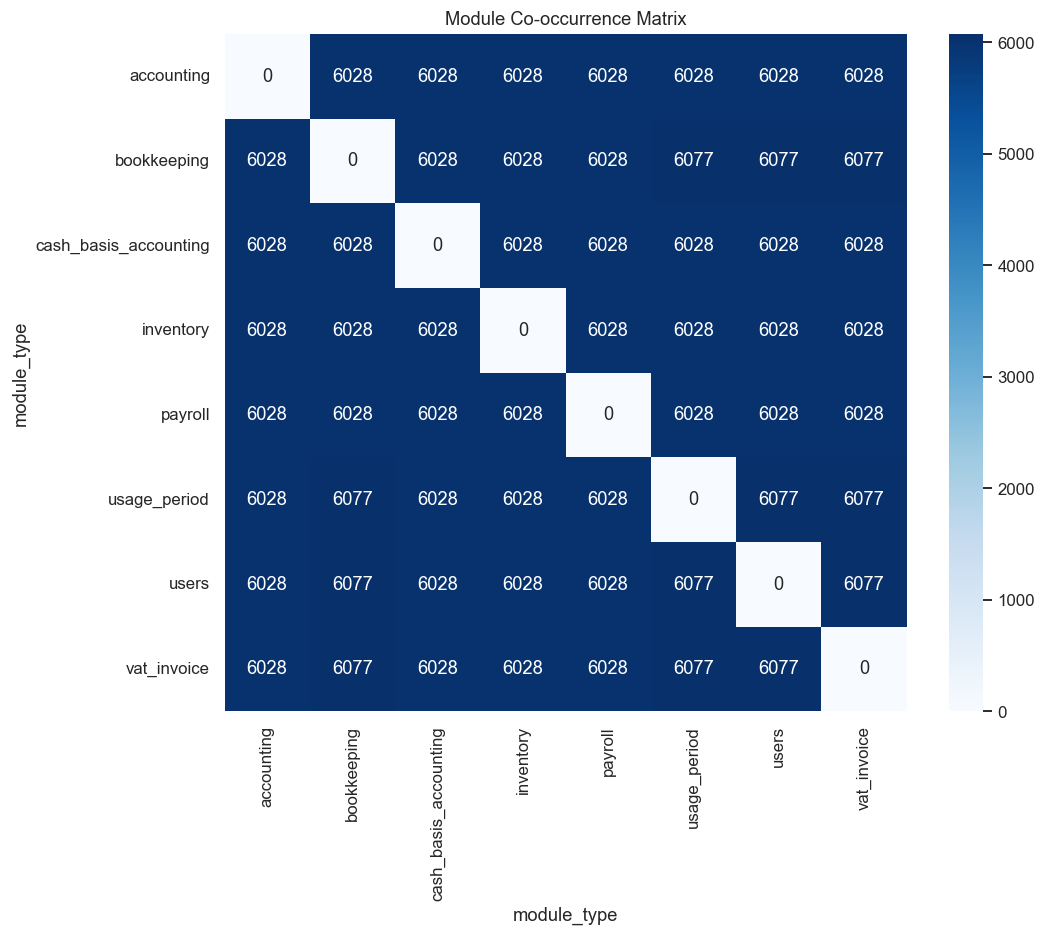

In [10]:
# Pivot to see which companies have which modules
pivot_df = pd.read_sql(text("""
    SELECT company_id, `key` as module_type, 1 as has_module
    FROM tmp_modules
"""), conn).pivot_table(index='company_id', columns='module_type', values='has_module', fill_value=0)

# Calculate co-occurrence matrix
cooccurrence = pivot_df.T.dot(pivot_df)
np.fill_diagonal(cooccurrence.values, 0) # clear diagonal for better heatmap contrast

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence, annot=True, fmt='g', cmap='Blues')
plt.title("Module Co-occurrence Matrix")
plt.show()


## 7. Billing Analysis

In [11]:
billing_df = pd.read_sql(text("""
    SELECT 
        CASE 
            WHEN next_billing < CURDATE() THEN 'Overdue'
            WHEN next_billing = CURDATE() THEN 'Due Today'
            WHEN next_billing > CURDATE() THEN 'Upcoming'
        END as billing_status,
        COUNT(*) as count
    FROM tmp_modules
    WHERE next_billing != '5757-01-01' -- Exclude placeholder far-future dates
    GROUP BY billing_status
"""), conn)
display(billing_df)


,billing_status,count
0,Overdue,39734
1,Upcoming,8676
2,Due Today,10


## 8. Module Lifecycle

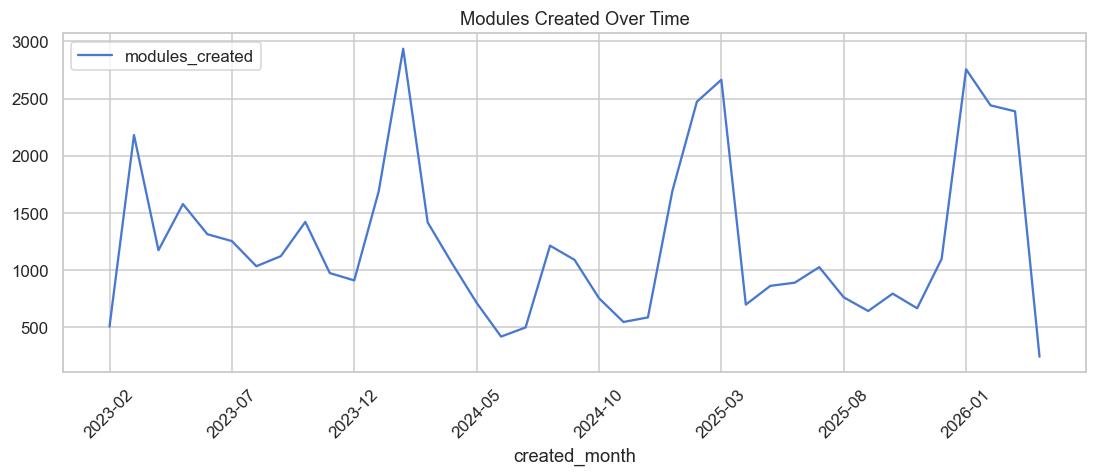

In [12]:
life_df = pd.read_sql(text("""
    SELECT 
        DATE_FORMAT(created_at, '%Y-%m') as created_month,
        COUNT(*) as modules_created
    FROM tmp_modules
    WHERE created_at IS NOT NULL
    GROUP BY created_month
    ORDER BY created_month
"""), conn)

life_df.plot(x='created_month', y='modules_created', title="Modules Created Over Time", figsize=(12, 4))
plt.xticks(rotation=45)
plt.show()


## 9. Soft Delete Analysis

In [13]:
del_df = pd.read_sql(text("""
    SELECT `key`, COUNT(*) as deleted_count
    FROM tmp_modules
    WHERE deleted_at IS NOT NULL
    GROUP BY `key`
    ORDER BY deleted_count DESC
"""), conn)
display(del_df)


,key,deleted_count


## 10. Module Value Analysis

In [14]:
val_df = pd.read_sql(text("""
    SELECT `key`, value, COUNT(*) as count
    FROM tmp_modules
    GROUP BY `key`, value
    ORDER BY `key`, count DESC
"""), conn)
display(val_df.head(20))


,key,value,count
0,accounting,1,5983
1,accounting,0,45
2,bookkeeping,1,5736
3,bookkeeping,0,333
4,bookkeeping,2,8
5,cash_basis_accounting,1,5507
6,cash_basis_accounting,0,521
7,inventory,1,5688
8,inventory,0,340
9,payroll,1,5501


## 11. Company Segmentation by Modules

,module_segment,num_companies
0,3. Heavy (4-6),49
1,4. Power (7+),6028


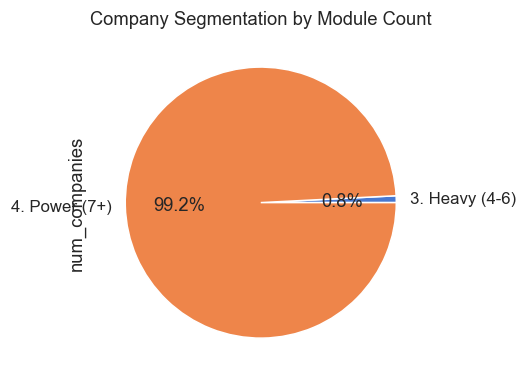

In [15]:
seg_df = pd.read_sql(text("""
    WITH comp_mods AS (
        SELECT company_id, COUNT(*) as mod_count
        FROM tmp_modules
        GROUP BY company_id
    )
    SELECT 
        CASE 
            WHEN mod_count = 1 THEN '1. Single Module'
            WHEN mod_count BETWEEN 2 AND 3 THEN '2. Multi (2-3)'
            WHEN mod_count BETWEEN 4 AND 6 THEN '3. Heavy (4-6)'
            ELSE '4. Power (7+)'
        END as module_segment,
        COUNT(*) as num_companies
    FROM comp_mods
    GROUP BY module_segment
    ORDER BY module_segment
"""), conn)
display(seg_df)
seg_df.plot.pie(y='num_companies', labels=seg_df['module_segment'], autopct='%1.1f%%', legend=False, title="Company Segmentation by Module Count")
plt.show()


## 12. Cross-Table Insights (Join with Subscriptions)

In [16]:
# Which module segments spend the most?
join_df = pd.read_sql(text("""
    WITH comp_mods AS (
        SELECT company_id, COUNT(*) as mod_count
        FROM tmp_modules
        GROUP BY company_id
    ),
    comp_subs AS (
        SELECT company_id, SUM(total) as total_spend
        FROM g4o_subscriptions
        WHERE currency_code = 'LAK' AND company_id != 97
        GROUP BY company_id
    )
    SELECT 
        CASE 
            WHEN m.mod_count = 1 THEN '1. Single Module'
            WHEN m.mod_count BETWEEN 2 AND 3 THEN '2. Multi (2-3)'
            WHEN m.mod_count BETWEEN 4 AND 6 THEN '3. Heavy (4-6)'
            ELSE '4. Power (7+)'
        END as module_segment,
        COUNT(m.company_id) as num_companies,
        SUM(s.total_spend) as segment_revenue,
        SUM(s.total_spend) / COUNT(m.company_id) as avg_revenue_per_company
    FROM comp_mods m
    LEFT JOIN comp_subs s ON m.company_id = s.company_id
    GROUP BY module_segment
    ORDER BY module_segment
"""), conn)
display(join_df)


,module_segment,num_companies,segment_revenue,avg_revenue_per_company
0,3. Heavy (4-6),49,1.666000e+07,3.400000e+05
1,4. Power (7+),6028,8.122742e+09,1.347502e+06


## 13. Key Findings & Actionable Insights

* **Popular Modules**: See the distribution to focus product development on highly adopted features.
* **Bundling Opportunities**: The co-occurrence matrix reveals which modules are frequently bought together. Create package deals to boost adoption.
* **Billing Health**: Check the overdue billing counts to prioritize follow-up communications.
* **Revenue Driver**: The cross-table join shows if adopting more modules leads to significantly higher lifetime revenue (LTV).

## 1. Data Loading & Cleaning

In [4]:
# EDA Engine v2: Deep-dive exploratory analysis
# - Parses g4o_modules JSON (text) safely
# - Filters "ghost modules" by aligning next_billing with latest subscription start_date
# - Implements pricing math exactly per business rules
# - Computes calculated MRR and compares it to subscription totals

import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 110})

# ---------------------------
# 1) Data Loading & Cleaning
# ---------------------------

# Assumption: `conn` is already created in an earlier cell.
# If not, this will fail loudly (so you know what to run).

# Load modules (EAV + JSON-as-text)
modules_raw = pd.read_sql(
    text(
        """
        SELECT
            company_id,
            `key`,
            value,
            next_billing,
            data,
            sequence,
            created_at,
            updated_at
        FROM g4o_modules
        WHERE company_id IS NOT NULL
          AND company_id != 97
        """
    ),
    conn,
)

# Load subscriptions (actual financials)
subs_cols = "company_id, status, start_date, end_date, total, currency_code"
# currency_code might exist; try selecting it. If it doesn't exist in your schema, rerun query below.
try:
    subs_raw = pd.read_sql(
        text(
            f"""
            SELECT {subs_cols}
            FROM g4o_subscriptions
            WHERE company_id IS NOT NULL
            """
        ),
        conn,
    )
except Exception:
    subs_cols = "company_id, status, start_date, end_date, total"
    subs_raw = pd.read_sql(
        text(
            f"""
            SELECT {subs_cols}
            FROM g4o_subscriptions
            WHERE company_id IS NOT NULL
            """
        ),
        conn,
    )

# --- Type casting + parsing helpers ---

def _to_datetime_norm(s: pd.Series) -> pd.Series:
    """Parse datetimes and normalize to midnight for stable alignment."""
    dt = pd.to_datetime(s, errors="coerce")
    return dt.dt.normalize()


def safe_json_load(x):
    """Safely parse JSON text stored in `g4o_modules.data`.

    Edge cases handled:
    - None / NaN -> {}
    - non-JSON strings -> {}
    - dict objects -> returned as-is
    """
    if x is None:
        return {}
    if isinstance(x, float) and np.isnan(x):
        return {}
    if isinstance(x, dict):
        return x
    s = str(x).strip()
    if not s or s.lower() in {"none", "null"}:
        return {}
    try:
        return json.loads(s)
    except Exception:
        return {}


# Parse datetime fields used for ghost-module filtering
modules_raw["next_billing_dt"] = pd.to_datetime(modules_raw["next_billing"], errors="coerce")
modules_raw["next_billing_norm"] = modules_raw["next_billing_dt"].dt.normalize()

subs_raw["start_date_dt"] = pd.to_datetime(subs_raw["start_date"], errors="coerce")
subs_raw["start_date_norm"] = subs_raw["start_date_dt"].dt.normalize()

# Cast numeric fields
modules_raw["value_num"] = pd.to_numeric(modules_raw["value"], errors="coerce").fillna(0.0)

# JSON text -> separate pricing columns (handle missing keys gracefully)
parsed = modules_raw["data"].apply(safe_json_load)
modules_raw["price"] = parsed.apply(lambda d: d.get("price", np.nan))
modules_raw["free_user"] = parsed.apply(lambda d: d.get("free_user", np.nan))
modules_raw["min_quantity"] = parsed.apply(lambda d: d.get("min_quantity", np.nan))

modules_raw["price_num"] = pd.to_numeric(modules_raw["price"], errors="coerce").fillna(0.0)
modules_raw["free_user_num"] = pd.to_numeric(modules_raw["free_user"], errors="coerce").fillna(0.0)
modules_raw["min_quantity_num"] = pd.to_numeric(modules_raw["min_quantity"], errors="coerce").fillna(0.0)

subs_raw["total_num"] = pd.to_numeric(subs_raw["total"], errors="coerce").fillna(0.0)

# If multi-currency exists, default to the most frequent currency.
# (Module prices don't carry currency explicitly in this dataset.)
if "currency_code" in subs_raw.columns:
    common_currency = subs_raw["currency_code"].mode(dropna=True)
    common_currency = common_currency.iloc[0] if len(common_currency) else None
    if common_currency is not None:
        subs_raw = subs_raw[subs_raw["currency_code"] == common_currency].copy()

# ---------------------------
# Ghost Modules filtering
# ---------------------------
# Business rule:
#   "Filter the modules table to only include rows where next_billing aligns with the most recent start_date
#    of the company's subscription."

latest_start = (
    subs_raw.dropna(subset=["start_date_norm"])
    .groupby("company_id", as_index=False)["start_date_norm"]
    .max()
    .rename(columns={"start_date_norm": "latest_start_norm"})
)

# Join so we can filter modules by equality on normalized dates
modules = modules_raw.merge(latest_start, on="company_id", how="inner")
modules = modules[modules["next_billing_norm"] == modules["latest_start_norm"]].copy()

# De-duplicate to one row per (company_id, key) after ghost filtering
# Prefer the newest record using created_at/updated_at.
modules["created_at_dt"] = pd.to_datetime(modules["created_at"], errors="coerce")
modules["updated_at_dt"] = pd.to_datetime(modules["updated_at"], errors="coerce")
modules["sort_ts"] = modules["created_at_dt"].fillna(modules["updated_at_dt"])
modules = (
    modules.sort_values(["company_id", "key", "sort_ts"])
    .groupby(["company_id", "key"], as_index=False)
    .tail(1)
    .copy()
)

print(f"Raw modules rows: {len(modules_raw):,}")
print(f"Modules rows after ghost filtering: {len(modules):,}")
print(f"Unique companies in ghost slice: {modules['company_id'].nunique():,}")


Raw modules rows: 48,420
Modules rows after ghost filtering: 23,665
Unique companies in ghost slice: 4,922


## 2. The MRR Engine (Data Engineering)

In [5]:

# ---------------------------
# 2) The MRR Engine (Data Engineering)
# ---------------------------

# usage_period is NOT billable; its value is a contract length multiplier (months)
usage_period_df = (
    modules.loc[modules["key"] == "usage_period", ["company_id", "value_num"]]
    .groupby("company_id", as_index=False)["value_num"]
    .max()
    .rename(columns={"value_num": "usage_period_mo"})
)

# Billable modules are everything except usage_period
billable = modules.loc[modules["key"] != "usage_period"].copy()

# Attach usage_period multiplier to every company
billable = billable.merge(usage_period_df, on="company_id", how="left")

# If usage_period is missing for a company, treat it as 0 (strict: avoid overstating MRR)
missing_usage = billable["usage_period_mo"].isna().sum()
billable["usage_period_mo"] = billable["usage_period_mo"].fillna(0.0)
if missing_usage:
    print(f"Warning: {missing_usage} billable module rows had missing usage_period; treated as 0.")

# Implement business logic exactly:
# - users: MAX(0, value - free_user) * price * usage_period
# - vat_invoice: value * price (ignore usage_period)
# - default (other modules): value * price * usage_period

billable["mrr_line"] = 0.0

users_mask = billable["key"] == "users"
vat_mask = billable["key"] == "vat_invoice"
other_mask = (~users_mask) & (~vat_mask)

billable.loc[users_mask, "mrr_line"] = (
    np.maximum(0.0, billable.loc[users_mask, "value_num"] - billable.loc[users_mask, "free_user_num"])
    * billable.loc[users_mask, "price_num"]
    * billable.loc[users_mask, "usage_period_mo"]
)

billable.loc[vat_mask, "mrr_line"] = (
    billable.loc[vat_mask, "value_num"] * billable.loc[vat_mask, "price_num"]
)

billable.loc[other_mask, "mrr_line"] = (
    billable.loc[other_mask, "value_num"]
    * billable.loc[other_mask, "price_num"]
    * billable.loc[other_mask, "usage_period_mo"]
)

mrr_by_company_module = (
    billable.groupby(["company_id", "key"], as_index=False)["mrr_line"].sum()
    .rename(columns={"key": "module_type", "mrr_line": "mrr_calc"})
)

mrr_total_df = (
    mrr_by_company_module.groupby("company_id", as_index=False)["mrr_calc"].sum()
    .rename(columns={"mrr_calc": "total_mrr_calc"})
)

# ---------------------------
# Receipt-only filter for "realized" revenue views
# ---------------------------

# Latest subscription per company based on most recent start_date
subs_latest = (
    subs_raw.dropna(subset=["start_date_norm"])
    .sort_values(["company_id", "start_date_norm"])
    .groupby("company_id", as_index=False)
    .tail(1)
    .copy()
)

# Receipt-only (paid cash) for MRR comparisons
receipt_companies = subs_latest.loc[subs_latest["status"] == "receipt", ["company_id", "status", "total_num"]]

mrr_receipt = mrr_total_df.merge(receipt_companies, on="company_id", how="inner")

print("Companies with calculated MRR:", mrr_total_df["company_id"].nunique())
print("Companies included in receipt-only comparisons:", mrr_receipt["company_id"].nunique())


Companies with calculated MRR: 4918
Companies included in receipt-only comparisons: 68


## 3. Distribution Analysis

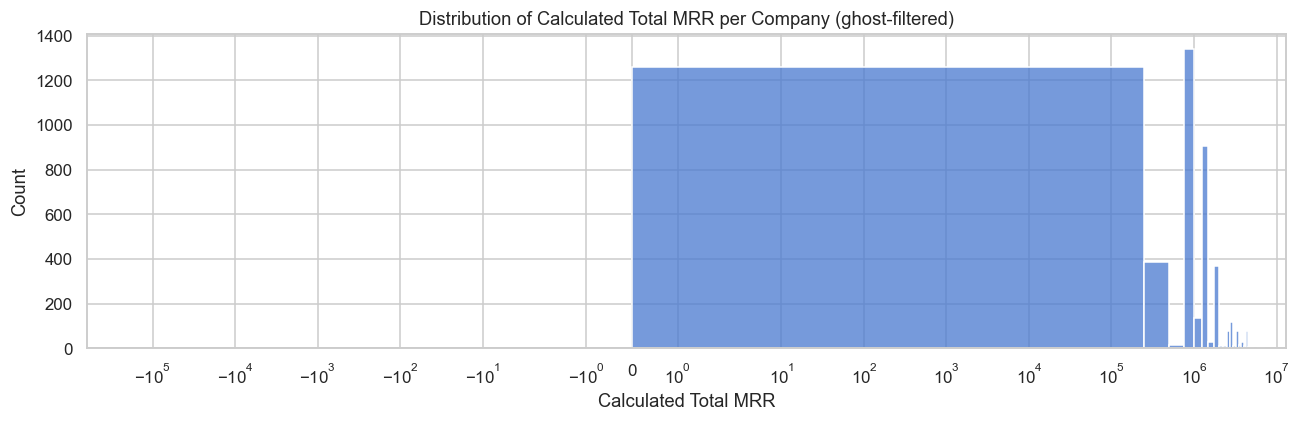

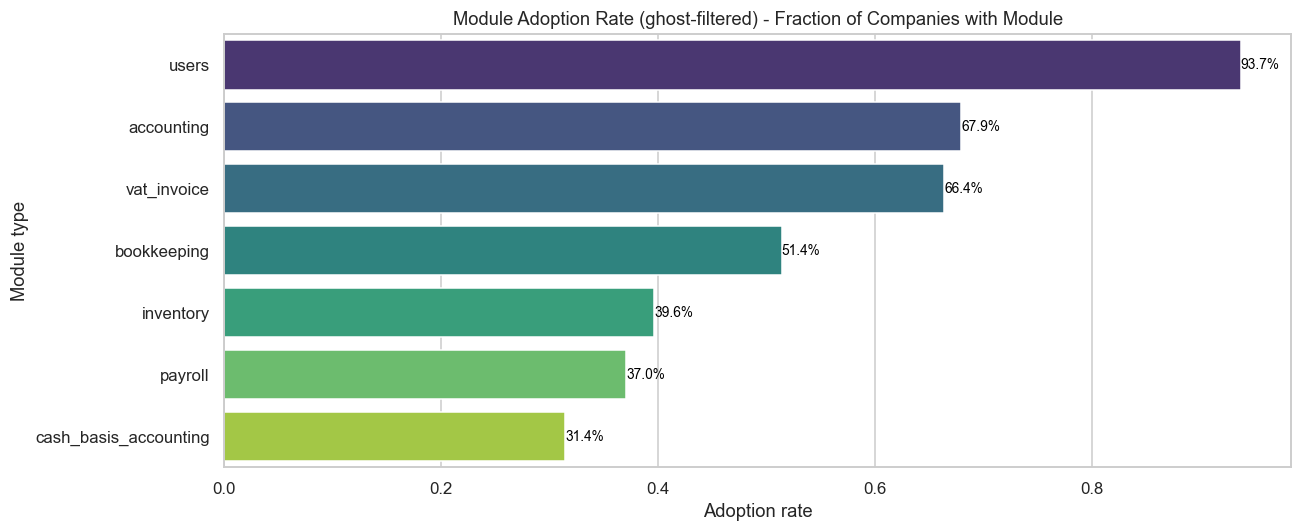

In [6]:
# ---------------------------
# 3) Distribution Analysis
# ---------------------------

# 3.1 Distribution of Total MRR per company
plt.figure(figsize=(12, 4))
ax = sns.histplot(mrr_total_df["total_mrr_calc"], bins=50, kde=False)
ax.set_title("Distribution of Calculated Total MRR per Company (ghost-filtered)")
ax.set_xlabel("Calculated Total MRR")

# symlog handles zeros gracefully
try:
    ax.set_xscale("symlog")
except Exception:
    pass

plt.tight_layout()
plt.show()

# 3.2 Adoption rate of individual modules (frequency across companies)
module_adoption = (
    mrr_by_company_module.groupby("module_type", as_index=False)["company_id"].nunique()
    .rename(columns={"company_id": "n_companies_with_module"})
)

n_companies_total = mrr_total_df["company_id"].nunique()
module_adoption["adoption_rate"] = module_adoption["n_companies_with_module"] / max(n_companies_total, 1)
module_adoption = module_adoption.sort_values("adoption_rate", ascending=False)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=module_adoption, y="module_type", x="adoption_rate", palette="viridis")
ax.set_title("Module Adoption Rate (ghost-filtered) - Fraction of Companies with Module")
ax.set_xlabel("Adoption rate")
ax.set_ylabel("Module type")

# Percentage labels
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width*100:.1f}%", (width, p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=9, color="black")

plt.tight_layout()
plt.show()

## 4. Pricing Anomaly Detection

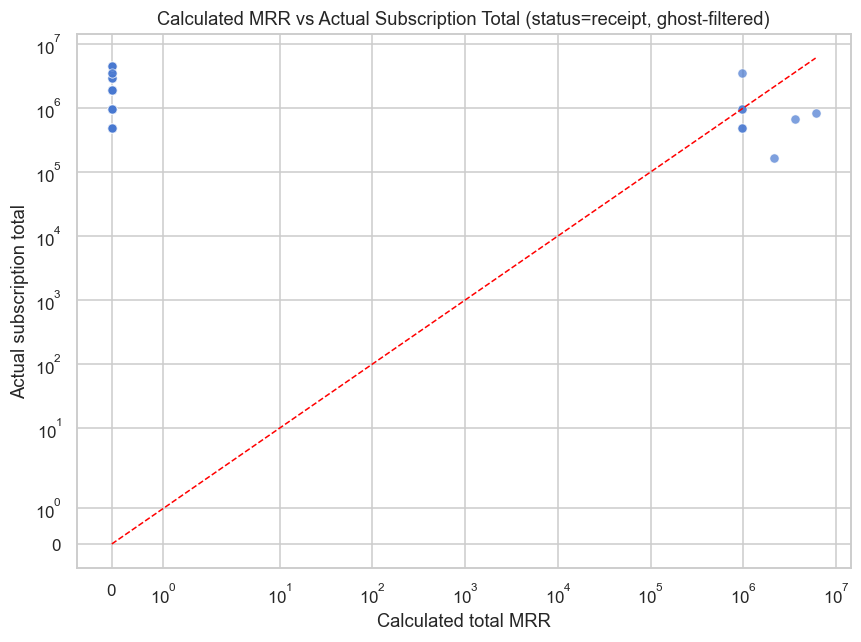

Top 10 companies by absolute variance (calc_total_mrr - actual_total):


,company_id,calc_total_mrr,actual_subscription_total,calc_minus_actual,abs_diff,rel_diff
15,7610,6000000.0,836384.0,5163616.0,5163616.0,6.173738
14,7598,0.0,4440000.0,-4440000.0,4440000.0,1.000000
66,8778,0.0,4440000.0,-4440000.0,4440000.0,1.000000
33,8356,0.0,4440000.0,-4440000.0,4440000.0,1.000000
17,7787,0.0,4440000.0,-4440000.0,4440000.0,1.000000
67,8788,0.0,3480000.0,-3480000.0,3480000.0,1.000000
56,8646,0.0,3480000.0,-3480000.0,3480000.0,1.000000
1,3174,0.0,3480000.0,-3480000.0,3480000.0,1.000000
0,2627,3570000.0,681205.0,2888795.0,2888795.0,4.240713
9,5569,0.0,2880000.0,-2880000.0,2880000.0,1.000000


In [7]:
# ---------------------------
# 4) Pricing Anomaly Detection
# ---------------------------

# Scatter comparing calculated MRR vs actual Subscriptions total
mrr_receipt = mrr_receipt.copy()
mrr_receipt["diff_calc_minus_actual"] = mrr_receipt["total_mrr_calc"] - mrr_receipt["total_num"]
mrr_receipt["abs_diff"] = mrr_receipt["diff_calc_minus_actual"].abs()

# Avoid divide-by-zero for relative variance
mrr_receipt["rel_diff"] = mrr_receipt["abs_diff"] / mrr_receipt["total_num"].replace(0, np.nan)

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(data=mrr_receipt, x="total_mrr_calc", y="total_num", alpha=0.7)
ax.plot([0, mrr_receipt[["total_mrr_calc", "total_num"]].max().max()],
        [0, mrr_receipt[["total_mrr_calc", "total_num"]].max().max()],
        linestyle="--", color="red", linewidth=1)
ax.set_title("Calculated MRR vs Actual Subscription Total (status=receipt, ghost-filtered)")
ax.set_xlabel("Calculated total MRR")
ax.set_ylabel("Actual subscription total")

# Use symlog for better visibility if there are zeros
try:
    ax.set_xscale("symlog")
    ax.set_yscale("symlog")
except Exception:
    pass

plt.tight_layout()
plt.show()

# Top 10 companies by highest mathematical variance (absolute)
top10 = (
    mrr_receipt.sort_values("abs_diff", ascending=False)
    .head(10)
    .loc[:, ["company_id", "total_mrr_calc", "total_num", "diff_calc_minus_actual", "abs_diff", "rel_diff"]]
    .copy()
    .rename(
        columns={
            "total_mrr_calc": "calc_total_mrr",
            "total_num": "actual_subscription_total",
            "diff_calc_minus_actual": "calc_minus_actual",
        }
    )
)

print("Top 10 companies by absolute variance (calc_total_mrr - actual_total):")
display(top10)

## 5. Cohort & Churn Signals

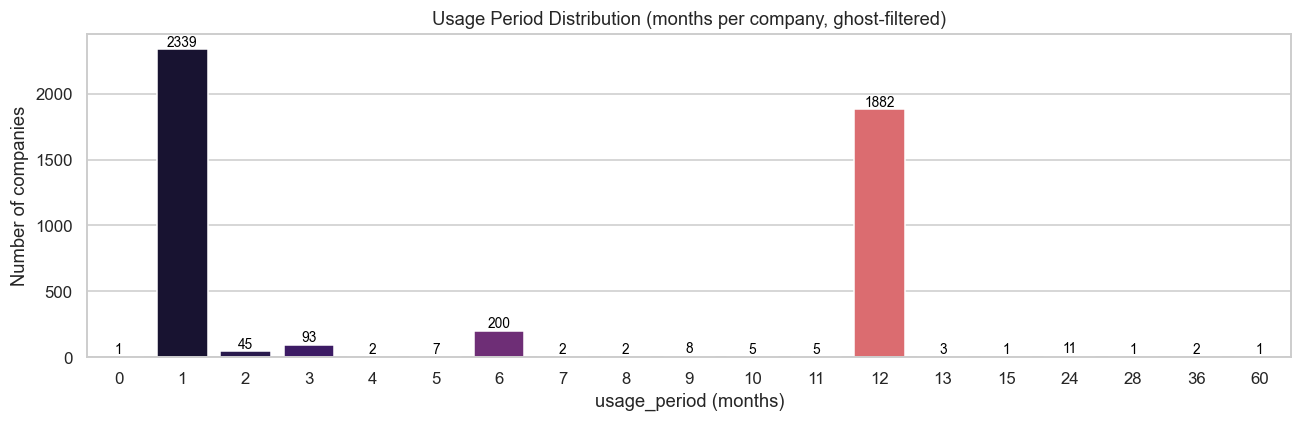

,status_group,n_companies,pct_companies
0,invoice (pipeline),5823,0.958676
1,receipt (realized),184,0.030293


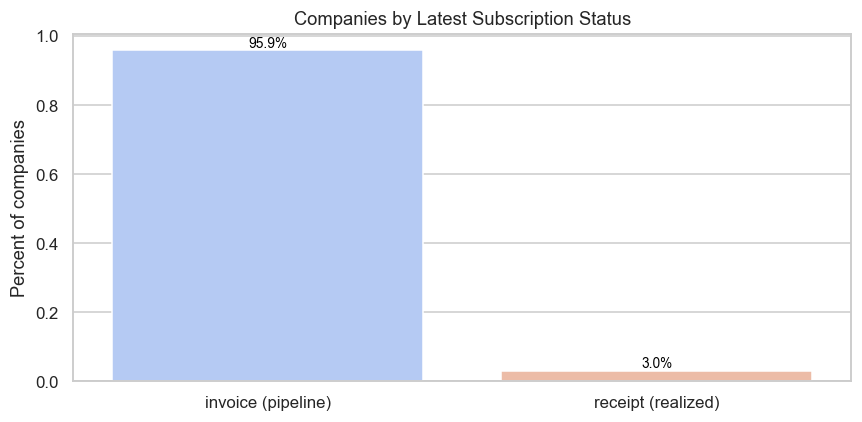

EDA Engine v2 completed.


In [8]:
# ---------------------------
# 5) Cohort & Churn Signals
# ---------------------------

# 5.1 usage_period distribution (how many months people buy)
usage_period_comp = usage_period_df.copy()
usage_period_comp["usage_period_mo"] = pd.to_numeric(usage_period_comp["usage_period_mo"], errors="coerce").fillna(0)

usage_dist = usage_period_comp["usage_period_mo"].value_counts().sort_index()
usage_dist_df = usage_dist.reset_index()
usage_dist_df.columns = ["usage_period_mo", "n_companies"]
usage_dist_df["pct_companies"] = usage_dist_df["n_companies"] / max(usage_period_comp.shape[0], 1)

plt.figure(figsize=(12, 4))
ax = sns.barplot(data=usage_dist_df, x="usage_period_mo", y="n_companies", palette="magma")
ax.set_title("Usage Period Distribution (months per company, ghost-filtered)")
ax.set_xlabel("usage_period (months)")
ax.set_ylabel("Number of companies")

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.0f}", (p.get_x() + p.get_width() / 2, h),
                ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
plt.show()

# 5.2 Pipeline vs realized: latest subscription status distribution
status_latest = subs_latest.dropna(subset=["status"]).copy()

n_companies = status_latest["company_id"].nunique()
status_counts = status_latest["status"].value_counts()

invoice_n = int(status_counts.get("invoice", 0))
receipt_n = int(status_counts.get("receipt", 0))

invoice_pct = invoice_n / max(n_companies, 1)
receipt_pct = receipt_n / max(n_companies, 1)

churn_df = pd.DataFrame(
    {
        "status_group": ["invoice (pipeline)", "receipt (realized)"],
        "n_companies": [invoice_n, receipt_n],
        "pct_companies": [invoice_pct, receipt_pct],
    }
)

display(churn_df)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=churn_df, x="status_group", y="pct_companies", palette="coolwarm")
ax.set_title("Companies by Latest Subscription Status")
ax.set_xlabel("")
ax.set_ylabel("Percent of companies")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
plt.show()

print("EDA Engine v2 completed.")